# Inverzní analýza: 
MCMC + PCE — modul pružnosti nosníku

Prostě podepřený nosník, síla uprostřed rozpětí:

$$f_{max} = \frac{F L^3}{48 E I}$$

Provedeme ohybovou zkoušku (různé síly, naměřený průhyb) a zpětně odhadneme $E$.

Postupuji:
1. Fyzikální model a data
2. Bayesovská inverze pomocí MCMC (plný model)
3. PCE surogát
4. MCMC znovu s PCE surogátem
5. Srovnání

UQpy dokumentace:
- https://uqpyproject.readthedocs.io/en/latest/auto_examples/inference/bayes_parameter_estimation/
- https://uqpyproject.readthedocs.io/en/latest/surrogates/polynomial_chaos.html

In [12]:
# Import knihoven
import numpy as np
import matplotlib.pyplot as plt
import dill, time, os

from UQpy.distributions import Uniform, JointIndependent, Normal
from UQpy.run_model.RunModel import RunModel
from UQpy import PythonModel
from UQpy.inference.inference_models.ComputationalModel import ComputationalModel
from UQpy.inference import BayesParameterEstimation
from UQpy.sampling.mcmc.MetropolisHastings import MetropolisHastings
from UQpy.surrogates.polynomial_chaos.polynomials.TotalDegreeBasis import TotalDegreeBasis
from UQpy.surrogates.polynomial_chaos.regressions.LeastSquareRegression import LeastSquareRegression
from UQpy.surrogates.polynomial_chaos.PolynomialChaosExpansion import PolynomialChaosExpansion

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

def acc_rate(mcmc):
    v = mcmc.acceptance_rate
    return v[0] if hasattr(v, '__len__') else v

print("Knihovny nacteny.")

Knihovny nacteny.


## Krok 1: Fyzikální model a data

In [14]:
# f_max = F*L^3/(48*E*I)
L, I_MOM, E_TRUE = 2.0, 4.0e-6, 210e9          # [m], [m^4], [Pa] (E_TRUE budeme hledat)
F_GRID = np.array([1000., 2000., 3000., 4000., 5000., 6000., 7000., 8000.])  # [N]

def prehyb_nosniku(F, E, L=L, I=I_MOM):
    return F * L**3 / (48.0 * E * I)

f_teoreticke = prehyb_nosniku(F_GRID, E_TRUE)
print(f"L={L} m, I={I_MOM:.2e} m^4, E_TRUE={E_TRUE:.2e} Pa")
for F_i, f_i in zip(F_GRID, f_teoreticke):
    print(f"  F={F_i:6.0f} N -> f={f_i*1000:6.3f} mm")

L=2.0 m, I=4.00e-06 m^4, E_TRUE=2.10e+11 Pa
  F=  1000 N -> f= 0.198 mm
  F=  2000 N -> f= 0.397 mm
  F=  3000 N -> f= 0.595 mm
  F=  4000 N -> f= 0.794 mm
  F=  5000 N -> f= 0.992 mm
  F=  6000 N -> f= 1.190 mm
  F=  7000 N -> f= 1.389 mm
  F=  8000 N -> f= 1.587 mm


In [15]:
# Synteticka "namerena" data = teorie + sum senzoru
SENSOR_STD = 1.0e-5  # [m]
noise = Normal(loc=0., scale=SENSOR_STD).rvs(nsamples=len(F_GRID), random_state=2024).reshape(-1)
data_mereni = f_teoreticke + noise

print("Namerena data:")
for F_i, d_i in zip(F_GRID, data_mereni):
    print(f"  F={F_i:6.0f} N -> namereno {d_i*1000:6.3f} mm")

Namerena data:
  F=  1000 N -> namereno  0.215 mm
  F=  2000 N -> namereno  0.404 mm
  F=  3000 N -> namereno  0.593 mm
  F=  4000 N -> namereno  0.792 mm
  F=  5000 N -> namereno  1.001 mm
  F=  6000 N -> namereno  1.202 mm
  F=  7000 N -> namereno  1.363 mm
  F=  8000 N -> namereno  1.574 mm


## Krok 2: Model přes `UQpy.RunModel`

In [17]:
%%writefile beam_model.py
import numpy as np, time

L, I_MOM = 2.0, 4.0e-6
F_GRID = np.array([1000., 2000., 3000., 4000., 5000., 6000., 7000., 8000.])
SIMULATED_COST = 0.02  # [s] - umele zpomaleni, simuluje drahou MKP simulaci

def model_beam_deflection(samples):
    time.sleep(SIMULATED_COST)
    E = float(samples[0])
    return F_GRID * L**3 / (48.0 * E * I_MOM)

Overwriting beam_model.py


In [44]:
SIMULATED_COST = 0.02  # stejna hodnota jako v beam_model.py, jen pro vypisy

model_full = PythonModel(model_script='beam_model.py', model_object_name='model_beam_deflection', var_names=['E'])
h_func_full = RunModel(model=model_full)

t0 = time.time()
h_func_full.run(samples=np.array([[E_TRUE]]))
t1 = time.time()

vysledek = np.array(h_func_full.qoi_list[0])
print("RunModel:", np.round(vysledek*1000, 4), "mm")
print("teorie  :", np.round(f_teoreticke*1000, 4), "mm")
print(f"cas 1 vyhodnoceni: {t1-t0:.4f} s")
assert np.allclose(vysledek, f_teoreticke)
print("Model zabalen do UQpy.RunModel.")

RunModel: [0.1984 0.3968 0.5952 0.7937 0.9921 1.1905 1.3889 1.5873] mm
teorie  : [0.1984 0.3968 0.5952 0.7937 0.9921 1.1905 1.3889 1.5873] mm
cas 1 vyhodnoceni: 0.0209 s
Model zabalen do UQpy.RunModel.


## Krok 3: Bayesovská inverze pomocí MCMC (plný model)

- **Prior**: co víme o $E$ před měřením
- **Likelihood**: data = model + Gaussovský šum.

MCMC spouštím po blocích, abych v konzoli viděl průběžnou konvergenci.

In [20]:
prior_E = Uniform(loc=100e9, scale=250e9)   # E ~ Uniform[100, 350] GPa
prior = JointIndependent(marginals=[prior_E])
error_covariance = SENSOR_STD ** 2

inference_model_full = ComputationalModel(n_parameters=1, runmodel_object=h_func_full,
                                           error_covariance=error_covariance, prior=prior)
print("Prior: Uniform(100,350) GPa | E_TRUE v prioru:", 100e9 <= E_TRUE <= 350e9)
print(">>> ComputationalModel (plny model) vytvoren.")

Prior: Uniform(100,350) GPa | E_TRUE v prioru: True
>>> ComputationalModel (plny model) vytvoren.


In [21]:
proposal = Normal(scale=3e9)
mcmc_full = MetropolisHastings(jump=2, burn_length=100, proposal=proposal, seed=[160e9], random_state=42)
bayes_full = BayesParameterEstimation(inference_model=inference_model_full, data=data_mereni,
                                       sampling_class=mcmc_full, nsamples=None)

KROK, POCET_KROKU = 200, 5   # 5 bloku x 200 = 1000 vzorku
print("MCMC (plny model)...")
t_start_full = time.time()
for k in range(1, POCET_KROKU + 1):
    bayes_full.run(nsamples=KROK)
    v = mcmc_full.samples[:, 0]
    print(f"blok {k}/{POCET_KROKU} | n={len(v):4d} | E={v.mean()/1e9:7.2f}+/-{v.std()/1e9:5.2f} GPa | acc={acc_rate(mcmc_full):.3f}")
cas_full = time.time() - t_start_full
print(f"Hotovo za {cas_full:.2f} s")

MCMC (plny model)...
blok 1/5 | n= 200 | E= 210.80+/- 0.84 GPa | acc=0.338
blok 2/5 | n= 400 | E= 210.80+/- 0.78 GPa | acc=0.331
blok 3/5 | n= 600 | E= 210.82+/- 0.75 GPa | acc=0.329
blok 4/5 | n= 800 | E= 210.85+/- 0.74 GPa | acc=0.319
blok 5/5 | n=1000 | E= 210.85+/- 0.75 GPa | acc=0.317
Hotovo za 45.61 s


blok 2/5 | n= 400 | E= 210.80+/- 0.78 GPa | acc=0.331


blok 3/5 | n= 600 | E= 210.82+/- 0.75 GPa | acc=0.329


blok 4/5 | n= 800 | E= 210.85+/- 0.74 GPa | acc=0.319


blok 5/5 | n=1000 | E= 210.85+/- 0.75 GPa | acc=0.317
Hotovo za 45.83 s


Posterior E (plny model): 210.85 +/- 0.75 GPa
95% interval: [209.41, 212.34] GPa
E_TRUE=210.00 GPa, relativni chyba=0.405 %


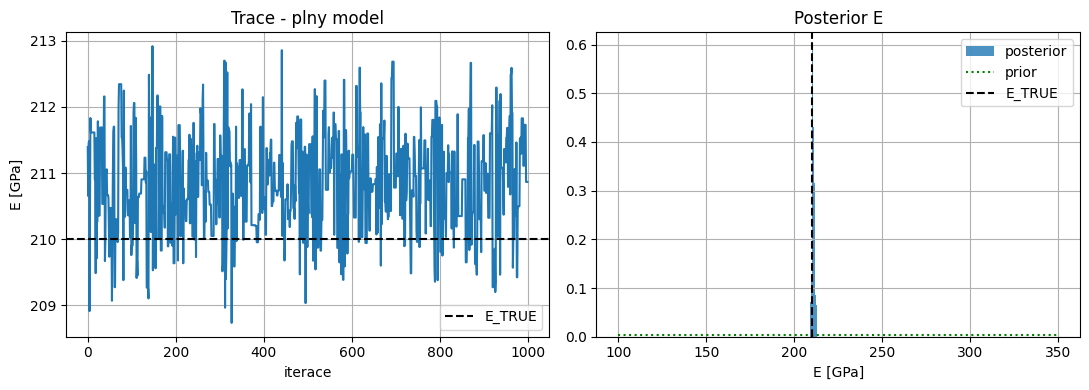

In [22]:
vzorky_full = mcmc_full.samples[:, 0]
print(f"Posterior E (plny model): {vzorky_full.mean()/1e9:.2f} +/- {vzorky_full.std()/1e9:.2f} GPa")
print(f"95% interval: [{np.percentile(vzorky_full,2.5)/1e9:.2f}, {np.percentile(vzorky_full,97.5)/1e9:.2f}] GPa")
print(f"E_TRUE={E_TRUE/1e9:.2f} GPa, relativni chyba={abs(vzorky_full.mean()-E_TRUE)/E_TRUE*100:.3f} %")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(vzorky_full/1e9); ax[0].axhline(E_TRUE/1e9, color='k', ls='--', label='E_TRUE')
ax[0].set(title='Trace - plny model', xlabel='iterace', ylabel='E [GPa]'); ax[0].legend()

ax[1].hist(vzorky_full/1e9, bins=30, density=True, alpha=0.8, label='posterior')
x_p = np.linspace(100, 350, 200)
ax[1].plot(x_p, prior_E.pdf(x_p.reshape(-1,1)*1e9)*1e9, 'g:', label='prior')
ax[1].axvline(E_TRUE/1e9, color='k', ls='--', label='E_TRUE')
ax[1].set(title='Posterior E', xlabel='E [GPa]'); ax[1].legend()
plt.tight_layout(); plt.show()

## Krok 4: PCE 

In [24]:
N_TRAIN = 25
X_train = prior_E.rvs(nsamples=N_TRAIN, random_state=7)
h_func_train = RunModel(model=model_full)

print(f"Trenuji PCE na {N_TRAIN} vzorcich z prioru...")
Y_train = np.zeros((N_TRAIN, len(F_GRID)))
t0 = time.time()
for i in range(N_TRAIN):
    h_func_train.run(samples=np.array([[X_train[i, 0]]]))
    Y_train[i, :] = h_func_train.qoi_list[-1]
    if (i + 1) % 5 == 0:
        print(f"  [{i+1}/{N_TRAIN}] E={X_train[i,0]/1e9:.1f} GPa")
print(f"Data hotova za {time.time()-t0:.2f} s (min. teoreticky {N_TRAIN*SIMULATED_COST:.2f} s)")

Trenuji PCE na 25 vzorcich z prioru...
  [5/25] E=344.5 GPa
  [10/25] E=225.0 GPa
  [15/25] E=172.0 GPa
  [20/25] E=106.2 GPa
  [25/25] E=327.3 GPa
Data hotova za 0.51 s (min. teoreticky 0.50 s)


  [20/25] E=106.2 GPa
  [25/25] E=327.3 GPa
Data hotova za 0.51 s (min. teoreticky 0.50 s)


In [65]:
MAX_DEGREE = 4
polynomial_basis = TotalDegreeBasis(distributions=prior_E, max_degree=MAX_DEGREE)
pce_surrogate = PolynomialChaosExpansion(polynomial_basis=polynomial_basis, regression_method=LeastSquareRegression())
pce_surrogate.fit(X_train, Y_train)

print(f"Bazovych polynomu: {polynomial_basis.polynomials_number}")
print("LOO chyba:", pce_surrogate.leaveoneout_error())

mean_pce, var_pce = pce_surrogate.get_moments()
print(f"Moment (F={F_GRID[-1]:.0f} N): stred={mean_pce[-1]*1000:.4f} mm, std={np.sqrt(var_pce[-1])*1000:.4f} mm")

Bazovych polynomu: 5
LOO chyba: [0.0001141 0.0001141 0.0001141 0.0001141 0.0001141 0.0001141 0.0001141
 0.0001141]
Moment (F=8000 N): stred=1.6703 mm, std=0.6196 mm


In [26]:
N_TEST = 15
X_test = prior_E.rvs(nsamples=N_TEST, random_state=99)
h_func_test = RunModel(model=model_full)
Y_test_true = np.zeros((N_TEST, len(F_GRID)))
for i in range(N_TEST):
    h_func_test.run(samples=np.array([[X_test[i, 0]]]))
    Y_test_true[i, :] = h_func_test.qoi_list[-1]
Y_test_pce = pce_surrogate.predict(X_test)

val_error = pce_surrogate.validation_error(X_test, Y_test_true)
rel_error = np.linalg.norm(Y_test_true - Y_test_pce) / np.linalg.norm(Y_test_true)
print("UQpy validation_error:", val_error)
print(f"Relativni L2 chyba PCE: {rel_error*100:.5f} %")

UQpy validation_error: [0.0001066 0.0001066 0.0001066 0.0001066 0.0001066 0.0001066 0.0001066
 0.0001066]
Relativni L2 chyba PCE: 0.44676 %


## Krok 5: PCE do MCMC

In [29]:
with open('pce_surrogate.pkl', 'wb') as fh:
    dill.dump(pce_surrogate, fh)
print("PCE ulozen,", os.path.getsize('pce_surrogate.pkl'), "bajtu.")

PCE ulozen, 140398 bajtu.


In [30]:
%%writefile beam_pce_model.py
import dill, numpy as np, os

_zde = os.path.dirname(os.path.abspath(__file__))
with open(os.path.join(_zde, 'pce_surrogate.pkl'), 'rb') as f:
    _PCE = dill.load(f)

def model_beam_pce(samples):
    E = np.array(samples, dtype=float).reshape(1, -1)
    return np.ravel(_PCE.predict(E))

Overwriting beam_pce_model.py


In [31]:
model_pce = PythonModel(model_script='beam_pce_model.py', model_object_name='model_beam_pce', var_names=['E'])
h_func_pce = RunModel(model=model_pce)

t0 = time.time()
h_func_pce.run(samples=np.array([[E_TRUE]]))
t1 = time.time()
print("PCE   :", np.round(np.array(h_func_pce.qoi_list[0])*1000, 4), "mm")
print("presne:", np.round(f_teoreticke*1000, 4), "mm")
print(f"cas 1 vyhodnoceni PCE: {t1-t0:.6f} s (vs ~{SIMULATED_COST} s plny model)")

PCE   : [0.1981 0.3962 0.5943 0.7924 0.9905 1.1886 1.3867 1.5848] mm
presne: [0.1984 0.3968 0.5952 0.7937 0.9921 1.1905 1.3889 1.5873] mm
cas 1 vyhodnoceni PCE: 0.001000 s (vs ~0.02 s plny model)


## Krok 6: MCMC s PCE

In [33]:
inference_model_pce = ComputationalModel(n_parameters=1, runmodel_object=h_func_pce,
                                          error_covariance=error_covariance, prior=prior)
mcmc_pce = MetropolisHastings(jump=2, burn_length=100, proposal=proposal, seed=[160e9], random_state=42)
bayes_pce = BayesParameterEstimation(inference_model=inference_model_pce, data=data_mereni,
                                      sampling_class=mcmc_pce, nsamples=None)

print("MCMC (PCE surogat)...")
t_start_pce = time.time()
for k in range(1, POCET_KROKU + 1):
    bayes_pce.run(nsamples=KROK)
    v = mcmc_pce.samples[:, 0]
    print(f"blok {k}/{POCET_KROKU} | n={len(v):4d} | E={v.mean()/1e9:7.2f}+/-{v.std()/1e9:5.2f} GPa | acc={acc_rate(mcmc_pce):.3f}")
cas_pce = time.time() - t_start_pce
print(f"Hotovo za {cas_pce:.4f} s")

MCMC (PCE surogat)...
blok 1/5 | n= 200 | E= 210.43+/- 0.87 GPa | acc=0.324
blok 2/5 | n= 400 | E= 210.46+/- 0.78 GPa | acc=0.322
blok 3/5 | n= 600 | E= 210.50+/- 0.76 GPa | acc=0.322
blok 4/5 | n= 800 | E= 210.51+/- 0.77 GPa | acc=0.319
blok 5/5 | n=1000 | E= 210.56+/- 0.78 GPa | acc=0.314
Hotovo za 1.9183 s


blok 2/5 | n= 400 | E= 210.46+/- 0.78 GPa | acc=0.322


blok 3/5 | n= 600 | E= 210.50+/- 0.76 GPa | acc=0.322


blok 4/5 | n= 800 | E= 210.51+/- 0.77 GPa | acc=0.319


blok 5/5 | n=1000 | E= 210.56+/- 0.78 GPa | acc=0.314
Hotovo za 2.6225 s


## Krok 7: Srovnání výsledků

In [72]:
vzorky_pce = mcmc_pce.samples[:, 0]
print(f"E_TRUE                 : {E_TRUE/1e9:7.2f} GPa")
print(f"Posterior plny model   : {vzorky_full.mean()/1e9:7.2f} +/- {vzorky_full.std()/1e9:5.2f} GPa")
print(f"Posterior PCE surogat  : {vzorky_pce.mean()/1e9:7.2f} +/- {vzorky_pce.std()/1e9:5.2f} GPa")
print(f"Chyba (plny)           : {abs(vzorky_full.mean()-E_TRUE)/E_TRUE*100:.3f} %")
print(f"Chyba (PCE)            : {abs(vzorky_pce.mean()-E_TRUE)/E_TRUE*100:.3f} %")
print(f"Cas plny model : {cas_full:.2f} s | Cas PCE : {cas_pce:.4f} s | zrychleni {cas_full/cas_pce:.1f}x")

E_TRUE                 :  210.00 GPa
Posterior plny model   :  210.85 +/-  0.75 GPa
Posterior PCE surogat  :  210.56 +/-  0.78 GPa
Chyba (plny)           : 0.405 %
Chyba (PCE)            : 0.265 %
Cas plny model : 45.61 s | Cas PCE : 1.9183 s | zrychleni 23.8x


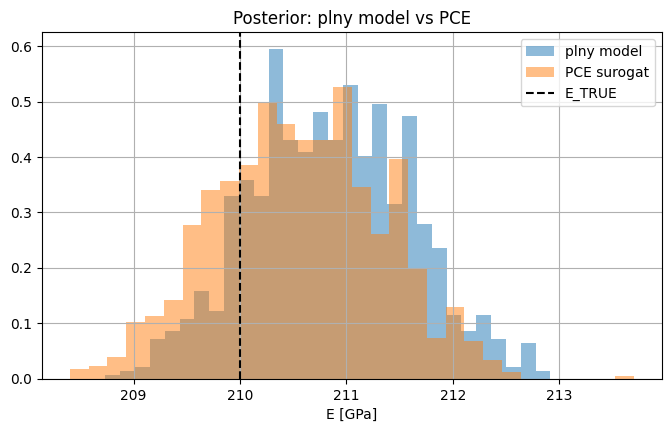

In [70]:
plt.figure()
plt.hist(vzorky_full/1e9, bins=30, alpha=0.5, density=True, label='plny model')
plt.hist(vzorky_pce/1e9, bins=30, alpha=0.5, density=True, label='PCE surogat')
plt.axvline(E_TRUE/1e9, color='k', ls='--', label='E_TRUE')
plt.xlabel('E [GPa]'); plt.title('Posterior: plny model vs PCE'); plt.legend(); plt.show()
